<a href="https://colab.research.google.com/github/Naimf/CVPR_CNN/blob/main/CNN_22_47715_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Data Loading and preprocessing

I used CIFAR-10 dataset for model training as it is easier to train .


Data prerprocess :

 - Resized images to 32x32

 - Applied normalization

 - Applied data augmentation (random horizontal flip)


In [15]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

## SPlit Datase into Train and Validation


After split -

-  Training 80%

- Validation 20%


Training Images:


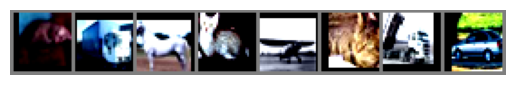

['cat', 'truck', 'horse', 'cat', 'airplane', 'cat', 'truck', 'automobile']
Validation Images:


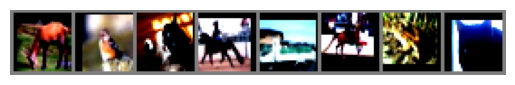

['deer', 'bird', 'cat', 'horse', 'truck', 'horse', 'frog', 'cat']


In [16]:
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

from torch.utils.data import random_split

train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size

trainset, valset = random_split(full_trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=128, shuffle=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = full_trainset.classes

import matplotlib.pyplot as plt
import numpy as np

# Function to show images
def imshow(img):
    img = img / 2 + 0.5   # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

print("Training Images:")
imshow(torchvision.utils.make_grid(images[:8]))
print([classes[labels[i]] for i in range(8)])

dataiter = iter(valloader)
images, labels = next(dataiter)

print("Validation Images:")
imshow(torchvision.utils.make_grid(images[:8]))
print([classes[labels[i]] for i in range(8)])

## Model Architecture

Two CNN models are implemented

## Basic CNN (without BatchNorm + Dropout)
- Convolution + ReLU + Pooling
- Fully Connected Layers

### Regularized CNN (with BatchNorm + Dropout)
- Batch Normalization
- Dropout
- Helps reduce overfitting and improve generalization

In [7]:
class CNN_Basic(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64*8*8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64*8*8)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x




In [17]:
class CNN_Regularized(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.fc1 = nn.Linear(128*4*4, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

## Model Summary

In [9]:
!pip install torchsummary
from torchsummary import summary

model = CNN_Regularized().to(device)
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Linear-7                  [-1, 128]         524,416
           Dropout-8                  [-1, 128]               0
            Linear-9                   [-1, 10]           1,290
Total params: 545,290
Trainable params: 545,290
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 0.85
Params size (MB): 2.08
Estimated Total Size (MB): 2.94
-------------------------------------------

## Training setup

 **Training Configuration**

- Loss: CrossEntropyLoss (standard for classifying 10 classes)
- Optimizer: Adam ( adaptive learning )
- Learning Rate: 0.001
- Scheduler: StepLR (reduces learning rate every 5 epochs)
- Epochs: 20

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_Regularized().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

## Trainging + Validation loop

In [20]:
train_acc_list = []
val_acc_list = []
train_loss_list = []
val_loss_list = []

epochs = 30

for epoch in range(epochs):

    # TRAIN
    model.train()
    running_loss = 0
    correct, total = 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    # VALIDATION
    model.eval()
    running_loss = 0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(valloader)
    val_acc = 100 * correct / total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.2f}%")
    print("-"*50)

Epoch [1/30]
Train Loss: 1.7081, Train Acc: 36.23%
Val   Loss: 1.3788, Val   Acc: 48.84%
--------------------------------------------------
Epoch [2/30]
Train Loss: 1.4037, Train Acc: 48.80%
Val   Loss: 1.1808, Val   Acc: 56.67%
--------------------------------------------------
Epoch [3/30]
Train Loss: 1.2491, Train Acc: 55.16%
Val   Loss: 1.3591, Val   Acc: 53.41%
--------------------------------------------------
Epoch [4/30]
Train Loss: 1.1551, Train Acc: 58.84%
Val   Loss: 1.0068, Val   Acc: 63.11%
--------------------------------------------------
Epoch [5/30]
Train Loss: 1.0996, Train Acc: 60.88%
Val   Loss: 1.0809, Val   Acc: 60.35%
--------------------------------------------------
Epoch [6/30]
Train Loss: 1.0405, Train Acc: 63.24%
Val   Loss: 0.8604, Val   Acc: 68.67%
--------------------------------------------------
Epoch [7/30]
Train Loss: 1.0005, Train Acc: 64.72%
Val   Loss: 0.9502, Val   Acc: 67.17%
--------------------------------------------------
Epoch [8/30]
Train L

## Accuracy Graph

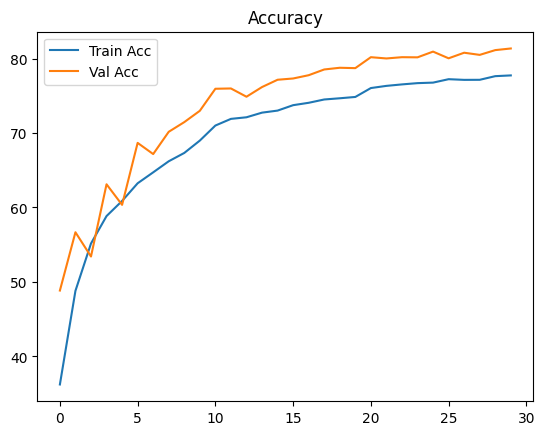

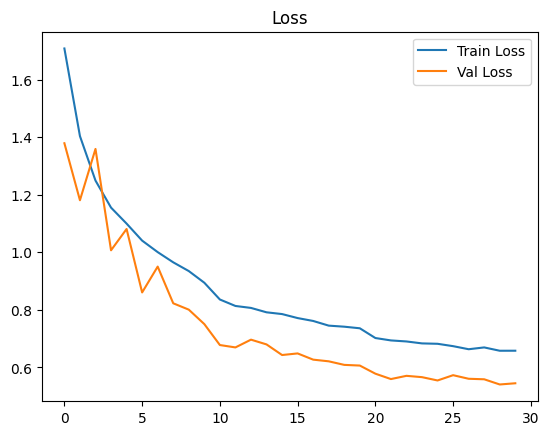

In [21]:
plt.plot(train_acc_list, label="Train Acc")
plt.plot(val_acc_list, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

## Model Evaluation

In [22]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

## Classification Report

In [23]:
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.83      0.81      0.82      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.75      0.71      0.73      1000
         cat       0.75      0.57      0.65      1000
        deer       0.75      0.82      0.79      1000
         dog       0.76      0.73      0.74      1000
        frog       0.78      0.91      0.84      1000
       horse       0.85      0.85      0.85      1000
        ship       0.88      0.93      0.90      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.81     10000
weighted avg       0.82      0.82      0.81     10000



## Confusion Mertix

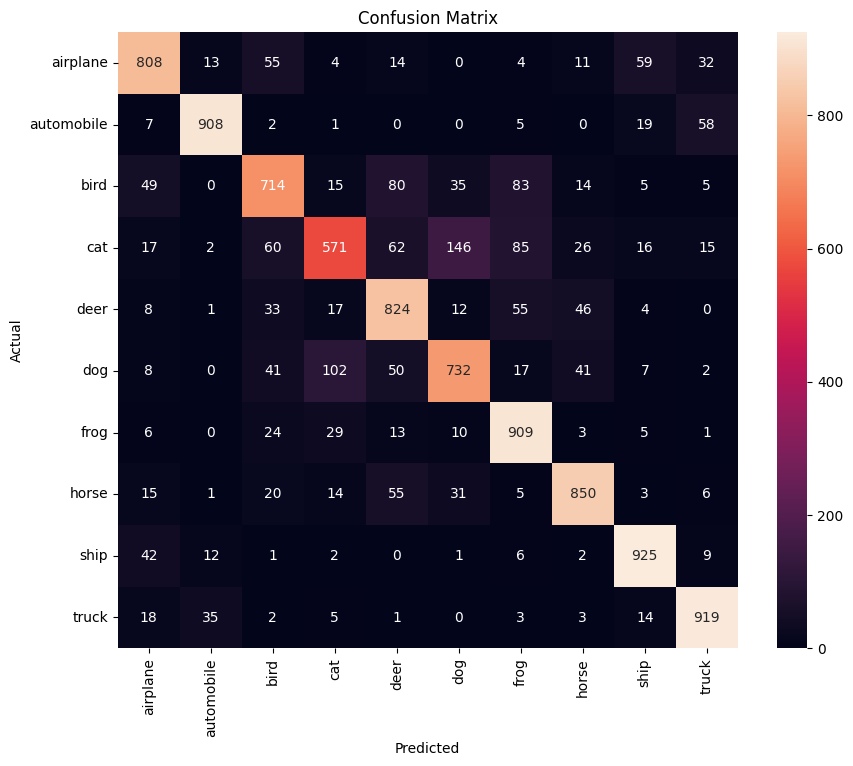

In [24]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Model Save

In [25]:
torch.save(model.state_dict(), "cnn_model.pth")

## Conclusion


The CNN model successfully classified images with good accuracy. The regularized model performed better due to Batch Normalization and Dropout.

## Future Work
- Use deeper networks (ResNet)
- Increase dataset size
- Apply more augmentation